## Build and query a simple reduced order model using ANN

In this tutorial we will show the typical workflow for the construction of the Reduced Order Model based only on the outputs of the higher-order model as in [Tutorial 1](tutorial-1.ipynb). Here, we replace the standard Radial Basis Function (`RBF`) framework used in [Tutorial 1](tutorial-1.ipynb) with an Artificial Neural Network (`ANN`).

### Install Dependencies
Install the necessary libraries for Reduced Order Modeling (`ezyrb`) and data handling (`datasets`).

In [1]:
%%capture
%pip install ezyrb datasets --no-cache-dir

### Import Libraries
Load standard numerical and plotting libraries alongside `ezyrb` components.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
import torch.nn as nn
import logging
from datasets import load_dataset
from ezyrb import POD, ANN, Database
from ezyrb import ReducedOrderModel as ROM

# Suppress unnecessary warnings and logging
logging.getLogger("datasets").setLevel(logging.ERROR)
%matplotlib inline

### Offline phase
Extract snapshots (high-fidelity solutions) and parameters from the dataset. We use `%%capture` here to avoid unauthenticated request warnings.

In [3]:
from IPython.utils import io

with io.capture_output(stdout=True, stderr=False) as captured:
    data_path = "kshitij-pandey/termal_dataset"
    snapshots_hf = load_dataset(data_path, "snapshots", split="train")
    param_hf = load_dataset(data_path, "params", split="train")
    triangles_hf = load_dataset(data_path, "triangles", split="train")
    coords_hf = load_dataset(data_path, "coords", split="train")

    def hf_to_numpy(ds):
        return ds.to_pandas().to_numpy()

    snapshots = hf_to_numpy(snapshots_hf)
    param = hf_to_numpy(param_hf)
    triangles = hf_to_numpy(triangles_hf)
    coords = hf_to_numpy(coords_hf)

print(snapshots.shape, param.shape)

(8, 304) (8, 2)


### Create Mesh Triangulation
Set up the triangulation object using the coordinates and connectivity for visualization.

In [4]:
x, y  = coords
from matplotlib.tri import Triangulation
triang = Triangulation(x, y, triangles)
triang = triang

### Visualize Snapshots
Plot the high-fidelity snapshots corresponding to different parameter values.

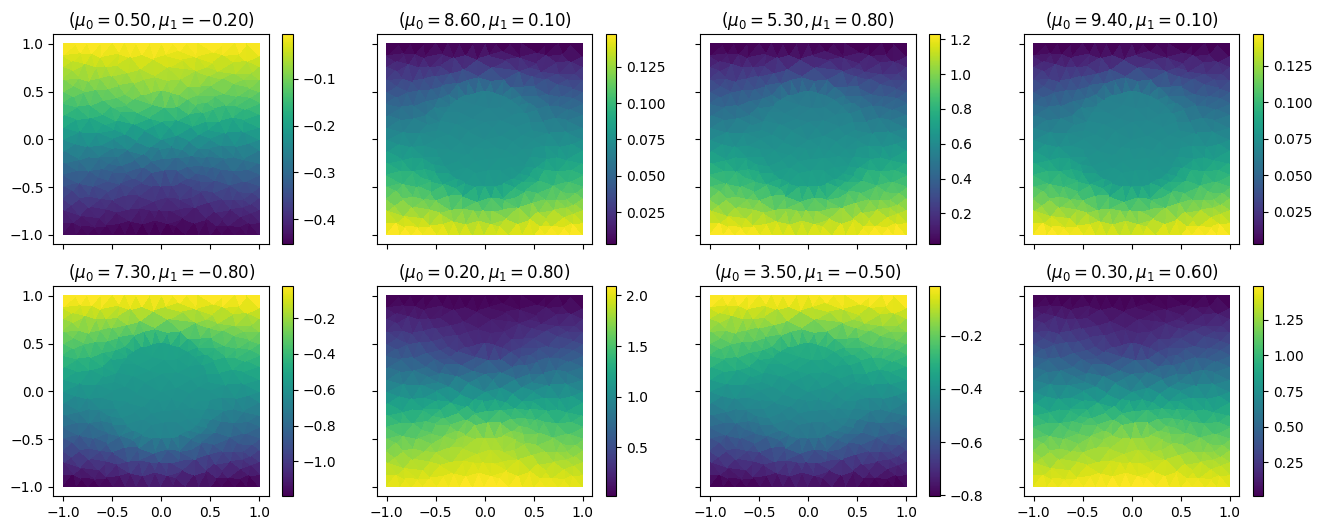

In [5]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(16, 6), sharey=True, sharex=True)
ax = ax.flatten()
for i in range(8):
    ax[i].triplot(triang, 'b-', lw=0.1)
    cm = ax[i].tripcolor(triang, snapshots[i])
    fig.colorbar(cm, ax=ax[i])
    ax[i].set_title(r'($\mu_0={:5.2f}, \mu_1={:5.2f})$'.format(*param[i]))

### Train Reduced Order Model
Define the POD reduction and ANN approximation architecture, then fit the ROM. `%%capture` is used to hide the training epoch logs.

In [6]:
from IPython.utils import io

with io.capture_output(stdout=True, stderr=False) as captured:
    db = Database(param, snapshots)
    n_snapshots = len(snapshots)
    pod = POD('svd', rank = n_snapshots - 1)

    layers = [10, 5]
    activation_func = nn.Tanh()
    stop_criteria = [20000, 1e-5]

    ann = ANN(layers, activation_func, stop_criteria)
    rom = ROM(db, pod, ann)
    rom.fit()

### Model Prediction
Query the trained ROM to predict the solution for a new, unseen parameter set.

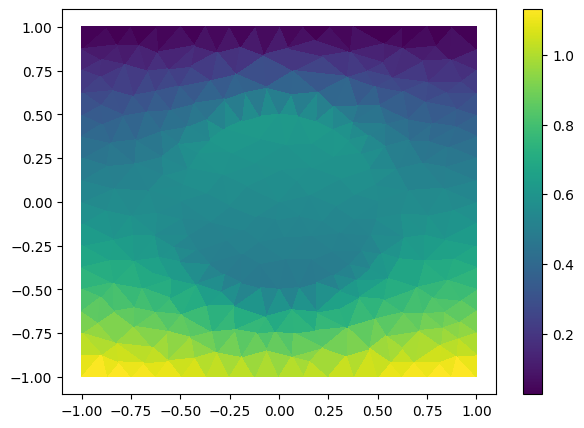

In [7]:
new_mu = [8, 1]
pred_sol = rom.predict(new_mu)

plt.figure(figsize=(7, 5))
plt.triplot(triang, 'b-', lw=0.1)
plt.tripcolor(triang, *pred_sol)
plt.colorbar();

### Error Approximation
Calculate the Leave-One-Out (LOO) error to validate model accuracy across the parameter space.

In [8]:
from IPython.utils import io

print("Calculating Leave-One-Out errors...")

with io.capture_output() as captured:
    errors = rom.loo_error()

for pt, error in zip(rom.database.parameters_matrix, errors):
    print(f"Parameters: {pt} | LOO Error: {error:.4e}")

Calculating Leave-One-Out errors...


Parameters: [ 0.5 -0.2] | LOO Error: 2.3828e-03
Parameters: [8.6 0.1] | LOO Error: 1.3258e-02
Parameters: [5.3 0.8] | LOO Error: 1.5617e-02
Parameters: [9.4 0.1] | LOO Error: 1.3369e-02
Parameters: [ 7.3 -0.8] | LOO Error: 2.0433e-03
Parameters: [0.2 0.8] | LOO Error: 2.1795e-02
Parameters: [ 3.5 -0.5] | LOO Error: 1.1100e-03
Parameters: [0.3 0.6] | LOO Error: 2.7223e-02


### Comparative Analysis
We compare the performance of the ANN-based model and the traditional Radial Basis Function (RBF) approach.
To have a fair comparision, we use same POD rank `n_snapshots - 1` for both models. The comparison is based on the Leave-One-Out (`LOO`) L2 relative error.

Mean LOO Error (ANN): 1.21e-02
Mean LOO Error (RBF): 4.45e-01


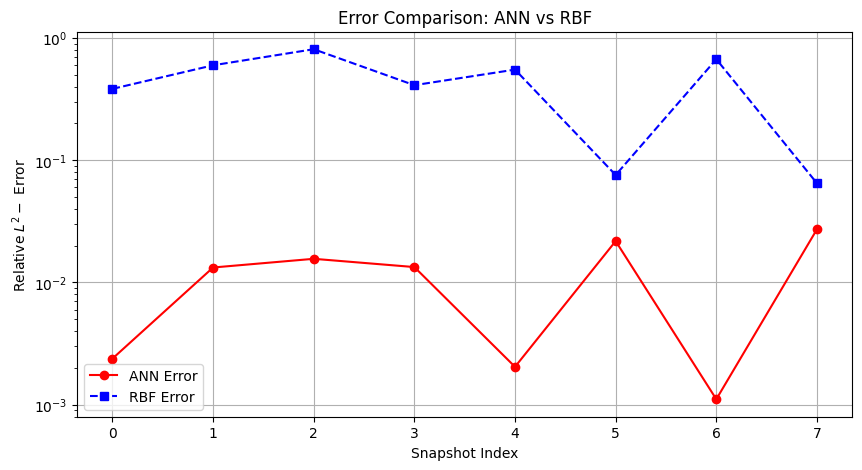

In [9]:
from ezyrb import RBF
from IPython.utils import io

pod_rbf = POD('svd', rank=n_snapshots - 1)
rbf = RBF()

with io.capture_output() as captured:
    rom_rbf = ROM(db, pod_rbf, rbf).fit()
    error_ann = rom.loo_error()
    error_rbf = rom_rbf.loo_error()

print(f"Mean LOO Error (ANN): {np.mean(error_ann):.2e}")
print(f"Mean LOO Error (RBF): {np.mean(error_rbf):.2e}")

plt.figure(figsize=(10, 5))
plt.plot(error_ann, 'ro-', label='ANN Error')
plt.plot(error_rbf, 'bs--', label='RBF Error')
plt.xlabel('Snapshot Index')
plt.ylabel(r'Relative $L^2-$ Error')
plt.title('Error Comparison: ANN vs RBF')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()